In [25]:
import gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns
from gym_sepsis.envs.sepsis_env import SepsisEnv

# =====================================================
# 1 Environment and Device
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FlattenObservationWrapper(gym.ObservationWrapper):
    """
    Automatically flattens all observations into 1D numpy arrays.
    Handles nested dicts and extra singleton dimensions like (46,1,1).
    """
    def __init__(self, env):
        super().__init__(env)
        flat_shape = int(np.prod(env.observation_space.shape))
        self.observation_space = gym.spaces.Box(
            low=np.float32(-np.inf), 
            high=np.float32(np.inf), 
            shape=(flat_shape,), 
            dtype=np.float32
        )

    def observation(self, obs):
        # Handle dict-based environments
        if isinstance(obs, dict):
            if "obs" in obs:
                obs = obs["obs"]
            elif "state" in obs:
                obs = obs["state"]
            else:
                obs = np.concatenate([np.ravel(v) for v in obs.values()])
        # Convert and flatten
        obs = np.array(obs, dtype=np.float32)
        return obs.flatten()

env = FlattenObservationWrapper(SepsisEnv())
state_size = env.observation_space.shape[0]
action_size = env.action_space.n


In [26]:

# =====================================================
# 2 Replay Buffer
# =====================================================

class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.vstack(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.vstack(next_states),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

# =====================================================
# 3 Dueling DQN Network
# =====================================================

class DuelingDQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DuelingDQN, self).__init__()
        
        # Shared feature extractor
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.5),
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.5)
        )
        
        # Separate streams
        self.value_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.LeakyReLU(0.5),
            nn.Linear(128, 1)  # scalar value of state
        )
        
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.LeakyReLU(0.5),
            nn.Linear(128, action_dim)  # advantage per action
        )

    def forward(self, x):
        # Flatten all inputs except batch dimension
        if isinstance(x, np.ndarray):
            x = torch.FloatTensor(x)
        if x.ndim == 1:
            x = x.unsqueeze(0)
        x = x.view(x.size(0), -1)

        features = self.feature(x)
        values = self.value_stream(features)
        advantages = self.advantage_stream(features)

        # Combine into Q-values (dueling formulation)
        q_vals = values + (advantages - advantages.mean(dim=1, keepdim=True))
        return q_vals


# =====================================================
# 4 Hyperparameters
# =====================================================

gamma = 0.99
lr = 1e-4
batch_size = 32
buffer_capacity = 100000
target_update_freq = 1000
num_episodes = 500  # adjust as needed
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 0.995

policy_net = DuelingDQN(state_size, action_size).to(device)
target_net = DuelingDQN(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
replay_buffer = ReplayBuffer(buffer_capacity)

# =====================================================
# 5 Training Loop
# =====================================================

episode_rewards = []
episode_lengths = []
loss_history = []
action_history = []

epsilon = epsilon_start
steps_done = 0

for episode in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0
    step_count = 0

    while not done:
        # ε-greedy policy
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_values = policy_net(torch.FloatTensor(state).to(device))
                action = torch.argmax(q_values).item()

        next_state, reward, done, _ = env.step(action)
        replay_buffer.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward
        step_count += 1
        steps_done += 1
        action_history.append(action)

        # Training step
        if len(replay_buffer) > batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

            states = torch.FloatTensor(states).to(device)
            actions = torch.LongTensor(actions).unsqueeze(1).to(device)
            rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
            next_states = torch.FloatTensor(next_states).to(device)
            dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

            q_values = policy_net(states).gather(1, actions)
            with torch.no_grad():
                next_actions = policy_net(next_states).argmax(1).unsqueeze(1)
                next_q_values = target_net(next_states).gather(1, next_actions)
                target_q = rewards + (gamma * next_q_values * (1 - dones))

            loss = nn.MSELoss()(q_values, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_history.append(loss.item())

        if steps_done % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

    epsilon = max(epsilon_end, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)
    episode_lengths.append(step_count)

    if (episode + 1) % 25 == 0:
        avg_reward = np.mean(episode_rewards[-25:])
        print(f"Episode {episode+1}/{num_episodes} | Avg Reward: {avg_reward:.2f} | Epsilon: {epsilon:.3f}")


Episode 25/500 | Avg Reward: 11.40 | Epsilon: 0.882
Episode 50/500 | Avg Reward: 15.00 | Epsilon: 0.778
Episode 75/500 | Avg Reward: 12.60 | Epsilon: 0.687
Episode 100/500 | Avg Reward: 11.40 | Epsilon: 0.606
Episode 125/500 | Avg Reward: 11.40 | Epsilon: 0.534
Episode 150/500 | Avg Reward: 13.80 | Epsilon: 0.471
Episode 175/500 | Avg Reward: 12.60 | Epsilon: 0.416
Episode 200/500 | Avg Reward: 13.80 | Epsilon: 0.367
Episode 225/500 | Avg Reward: 12.60 | Epsilon: 0.324
Episode 250/500 | Avg Reward: 11.40 | Epsilon: 0.286
Episode 275/500 | Avg Reward: 12.60 | Epsilon: 0.252
Episode 300/500 | Avg Reward: 12.60 | Epsilon: 0.222
Episode 325/500 | Avg Reward: 12.60 | Epsilon: 0.196
Episode 350/500 | Avg Reward: 13.80 | Epsilon: 0.173
Episode 375/500 | Avg Reward: 13.80 | Epsilon: 0.153
Episode 400/500 | Avg Reward: 10.20 | Epsilon: 0.135
Episode 425/500 | Avg Reward: 15.00 | Epsilon: 0.119
Episode 450/500 | Avg Reward: 15.00 | Epsilon: 0.105
Episode 475/500 | Avg Reward: 12.60 | Epsilon: 0.

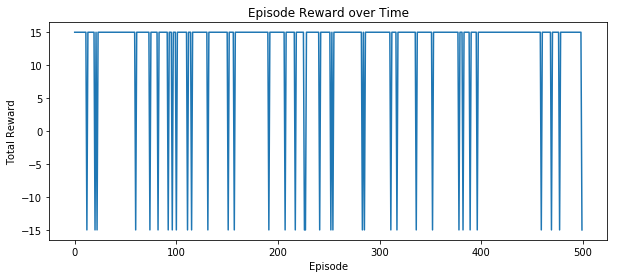

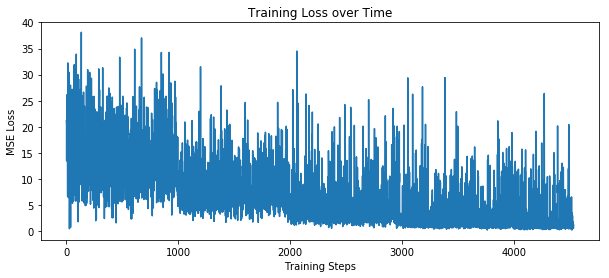

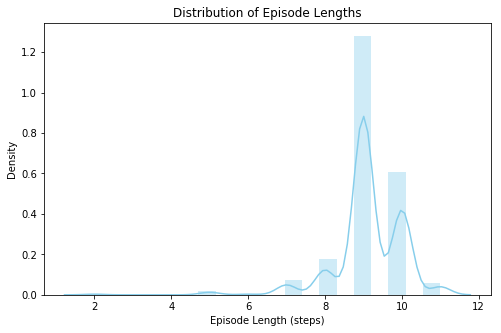

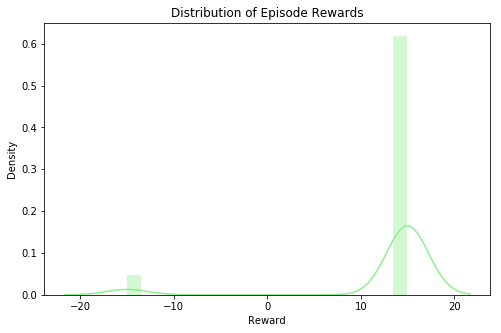

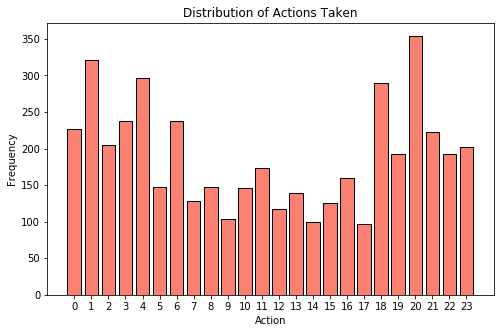

In [27]:

# =====================================================
# 6 Evaluation & Visualization
# =====================================================

# --- Reward Trend ---
plt.figure(figsize=(10,4))
plt.plot(episode_rewards)
plt.title("Episode Reward over Time")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

# --- Loss Trend ---
plt.figure(figsize=(10,4))
plt.plot(loss_history)
plt.title("Training Loss over Time")
plt.xlabel("Training Steps")
plt.ylabel("MSE Loss")
plt.show()

# --- Episode Length Distribution ---
plt.figure(figsize=(8,5))
sns.distplot(episode_lengths, bins=20, color='skyblue', kde=True)
plt.title("Distribution of Episode Lengths")
plt.xlabel("Episode Length (steps)")
plt.ylabel("Density")
plt.show()

# --- Reward Distribution ---
plt.figure(figsize=(8,5))
sns.distplot(episode_rewards, bins=20, color='lightgreen', kde=True)
plt.title("Distribution of Episode Rewards")
plt.xlabel("Reward")
plt.ylabel("Density")
plt.show()

# --- Action Distribution ---
plt.figure(figsize=(8,5))
plt.hist(action_history, bins=np.arange(action_size+1)-0.5, color='salmon', edgecolor='black', rwidth=0.8)
plt.title("Distribution of Actions Taken")
plt.xlabel("Action")
plt.ylabel("Frequency")
plt.xticks(np.arange(action_size))
plt.show()


In [29]:

# =====================================================
# 7 Feature Importance via Gradient Norm
# =====================================================

def compute_feature_importance(model, memory, batch_size=256):
    if len(memory) < batch_size:
        print("Not enough samples in memory.")
        return None, None

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    states = torch.FloatTensor(np.vstack(states)).to(device)
    next_states = torch.FloatTensor(np.vstack(next_states)).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    states.requires_grad = True

    q_values = model(states).gather(1, actions)
    with torch.no_grad():
        next_actions = model(next_states).argmax(1).unsqueeze(1)
        next_q = model(next_states).gather(1, next_actions)
        target_q = rewards + (gamma * next_q * (1 - dones))

    loss = (q_values - target_q).pow(2).mean()
    loss.backward(retain_graph=True)

    grad_mags = states.grad.abs().mean(dim=0).cpu().numpy()
    norm_grad = grad_mags / (grad_mags.sum() + 1e-8)

    plt.figure(figsize=(12,5))
    plt.bar(np.arange(len(norm_grad)), norm_grad, color='salmon')
    plt.title("Normalized Feature Importance (|∂Loss/∂Feature|)")
    plt.xlabel("Feature Index")
    plt.ylabel("Normalized Gradient Magnitude")
    plt.show()

    return grad_mags, norm_grad

grad_mags, norm_grad = compute_feature_importance(policy_net, replay_buffer)


TypeError: Population must be a sequence or set.  For dicts, use list(d).